## Exploration et Nettoyage

### importons les librairies

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# Chargement des données
df = pd.read_csv('Bakery.csv')
df.head()

,TransactionNo,Items,DateTime,Daypart,DayType
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
2,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend


In [37]:

# Informations de structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionNo  20507 non-null  int64 
 1   Items          20507 non-null  object
 2   DateTime       20507 non-null  object
 3   Daypart        20507 non-null  object
 4   DayType        20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [38]:

# Détection des valeurs manquantes
df.isnull().sum()


TransactionNo    0
Items            0
DateTime         0
Daypart          0
DayType          0
dtype: int64

In [39]:
# Suppression de colonnes non pertinentes
df_clean = df.drop(columns=['TransactionNo'])

# Imputation ou Nettoyage (Conversion en datetime)
df_clean['DateTime'] = pd.to_datetime(df_clean['DateTime'])
df_clean['Hour'] = df_clean['DateTime'].dt.hour
df_clean['Month'] = df_clean['DateTime'].dt.month
df_clean['DayOfWeek'] = df_clean['DateTime'].dt.dayofweek

df_clean.head()

,Items,DateTime,Daypart,DayType,Hour,Month,DayOfWeek
0,Bread,2016-10-30 09:58:11,Morning,Weekend,9,10,6
1,Scandinavian,2016-10-30 10:05:34,Morning,Weekend,10,10,6
2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend,10,10,6
3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend,10,10,6
4,Jam,2016-10-30 10:07:57,Morning,Weekend,10,10,6


## Agrégations

In [40]:
# Résumé statistique
df_clean.describe()

,DateTime,Hour,Month,DayOfWeek
count,20507,20507.000000,20507.000000,20507.000000
mean,2017-01-22 18:18:56.282196480,12.270883,6.026723,3.148486
min,2016-01-11 07:51:20,1.000000,1.000000,0.000000
25%,2016-11-25 09:55:08,10.000000,2.000000,1.000000
50%,2017-01-27 11:11:11,12.000000,5.000000,3.000000
75%,2017-03-25 11:51:41,14.000000,11.000000,5.000000
max,2017-12-03 16:28:00,23.000000,12.000000,6.000000
std,NaN,2.337201,4.140075,2.039248


In [41]:
# Matrice de covariance
df_clean.select_dtypes(include=[np.number]).cov()

,Hour,Month,DayOfWeek
Hour,5.462511,-0.386201,0.053748
Month,-0.386201,17.140220,0.289117
DayOfWeek,0.053748,0.289117,4.158532


In [42]:
# Matrice de corrélation
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()
corr_matrix

,Hour,Month,DayOfWeek
Hour,1.000000,-0.039913,0.011277
Month,-0.039913,1.000000,0.034245
DayOfWeek,0.011277,0.034245,1.000000


In [ ]:
# Groupby simple (Ventes par moment de la journée)
df_clean.groupby('Daypart')['Items'].count()

Daypart
Afternoon    11569
Evening        520
Morning       8404
Night           14
Name: Items, dtype: int64

In [45]:
# Taux d'activité
pivot_table = df_clean.groupby(['DayType', 'Daypart']).size().unstack()
pivot_table

Daypart,Afternoon,Evening,Morning,Night
DayType,,,,
Weekday,7273,356,5174,4
Weekend,4296,164,3230,10


## Visualisations données

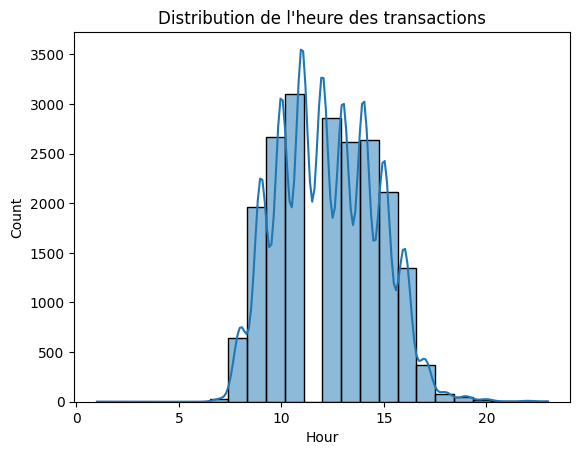

In [58]:
# Histogramme (Distribution de l'heure des transactions)
plt.title("Distribution de l'heure des transactions")
sns.histplot(df_clean['Hour'], kde=True, bins=24)
plt.show()

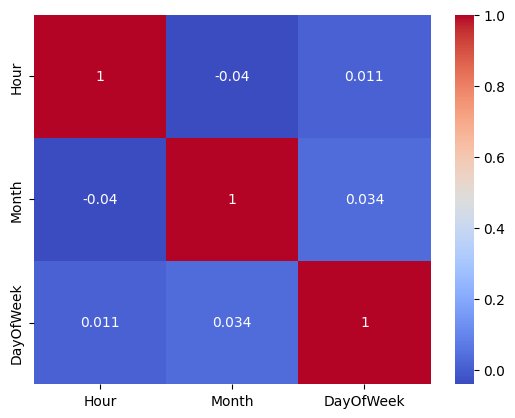

In [59]:
# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

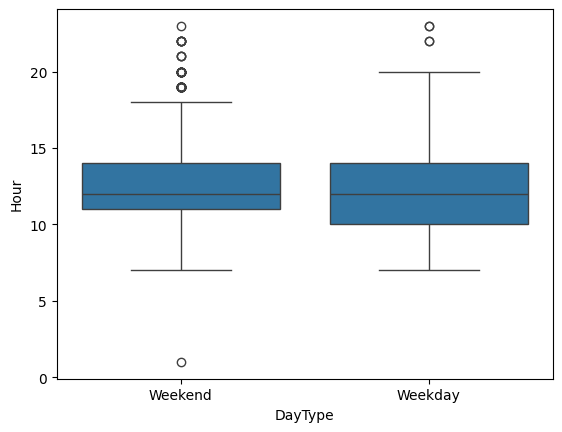

In [ ]:
#  Boxplot (Ventes par DayType)
sns.boxplot(x='DayType', y='Hour', data=df_clean)
plt.show()

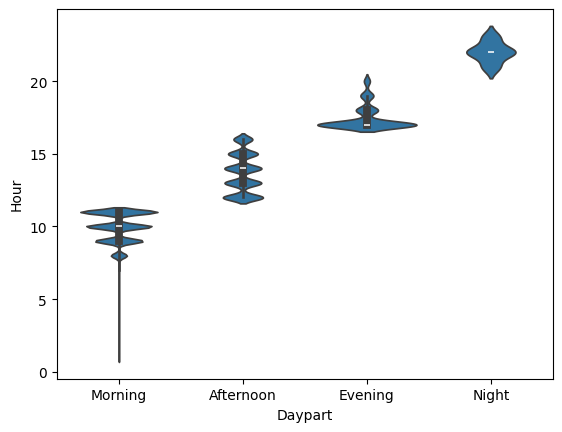

In [ ]:
# Violinplot
sns.violinplot(x='Daypart', y='Hour', data=df_clean)
plt.show()

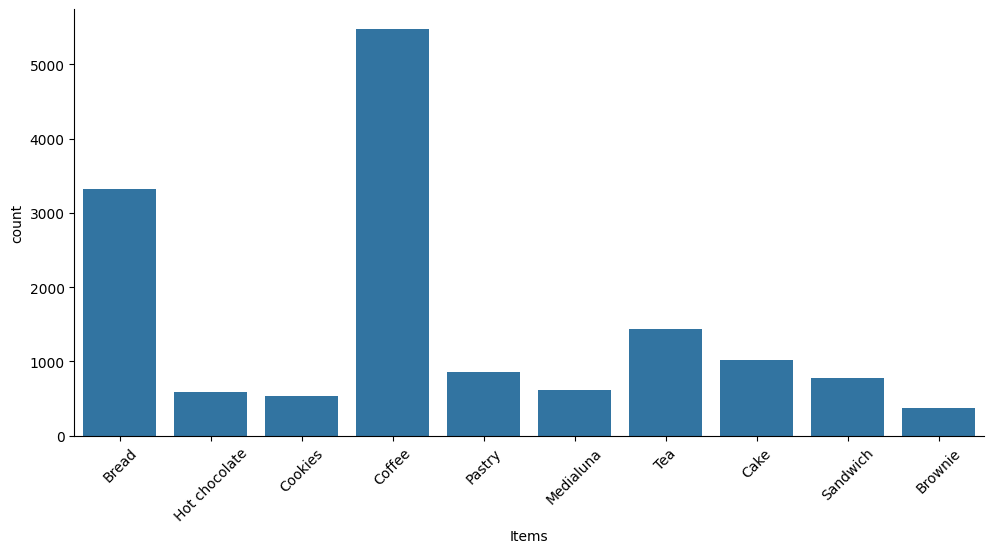

In [72]:
# Top 10 articles les plus vendus pour savoir lesquels ne doivent jamais être en rupture de stock
# ou sur lesquels il faut faire des prévisions très précises ou bien les promotions, ....
top_10 = df_clean['Items'].value_counts().head(10).index
sns.catplot(data=df_clean[df_clean['Items'].isin(top_10)], x='Items', kind='count', aspect=2)
plt.xticks(rotation=45)
plt.show()

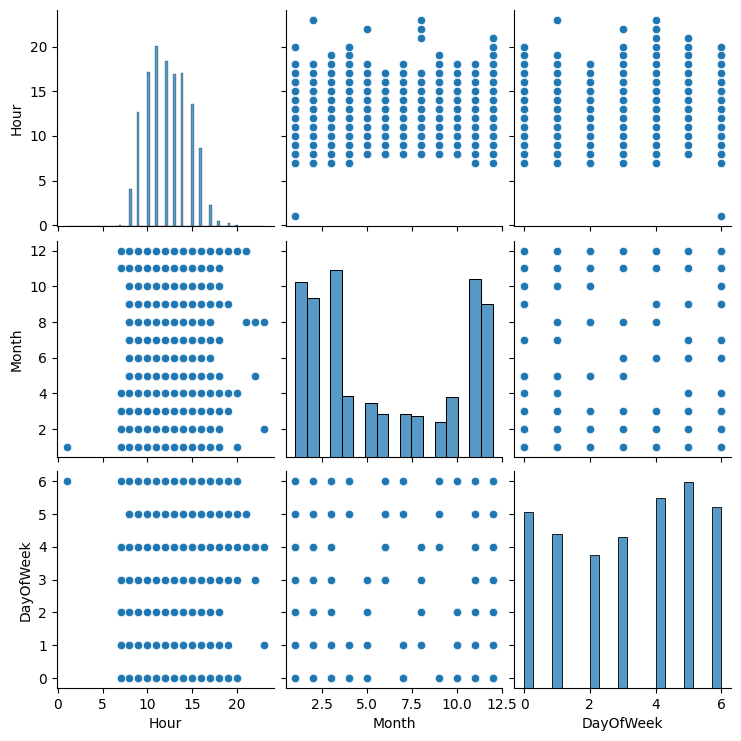

In [73]:
# Pairplot
# Les diagonales montrent la distribution de chaque variable (histogrammes).
# autres cases montrent comment deux variables réagissent l'une par rapport à l'autre.
sns.pairplot(df_clean[['Hour', 'Month', 'DayOfWeek']])
plt.show()

## Machine learning

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import learning_curve

In [75]:
# Chargement et préparation (Agrégation par jour/heure pour le forecasting)
# On crée un dataset "Features" (X) et "Target" (y = nombre de transactions)
data_ml = df_clean.groupby(['Month', 'DayOfWeek', 'Hour']).size().reset_index(name='SalesCount')
X = data_ml[['Month', 'DayOfWeek', 'Hour']]
y = data_ml['SalesCount']

X.head()

,Month,DayOfWeek,Hour
0,1,0,7
1,1,0,8
2,1,0,9
3,1,0,10
4,1,0,11


In [ ]:
# Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# l'arbre nous confirme en un coup d'œil si c'est l'heure ou le jour de la semaine qui prime sur l'activité
# contrairement à la regression linéaire qui prédit des valeurs continues. La boulangerie a des pics d'activités à certains moments seulement.

# Arbre de décision
model_tree = DecisionTreeRegressor(max_depth=3)
model_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


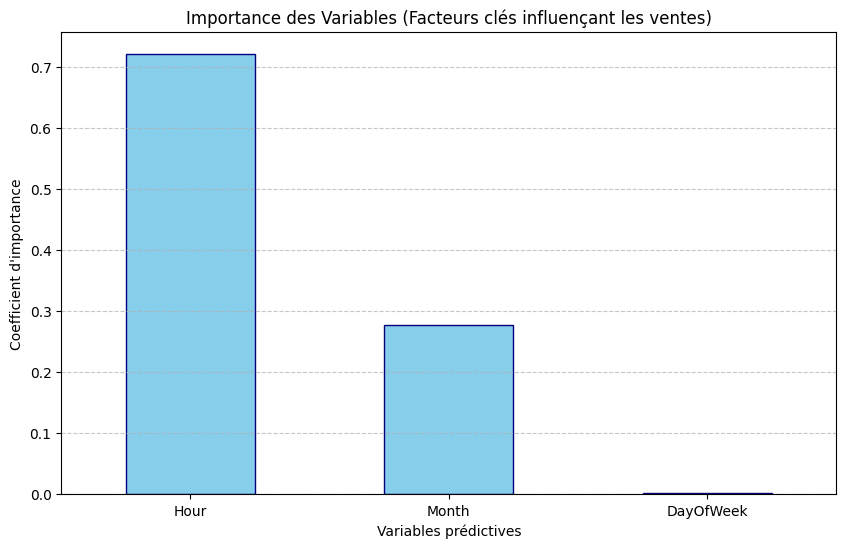

In [76]:
# Création de la série d'importances
importances = pd.Series(model_tree.feature_importances_, index=X.columns)

# Tri par importance décroissante pour une meilleure lecture
importances = importances.sort_values(ascending=False)

# Affichage en barres verticales
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='skyblue', edgecolor='navy')

plt.title("Importance des Variables (Facteurs clés influençant les ventes)")
plt.ylabel("Coefficient d'importance")
plt.xlabel("Variables prédictives")
plt.xticks(rotation=0) # Garde les noms des variables à l'horizontale
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

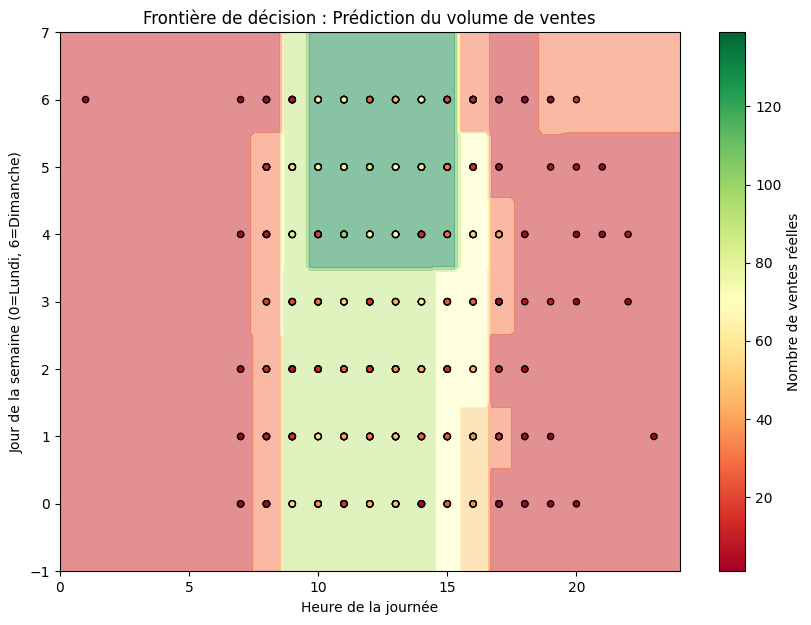

In [70]:
from sklearn.inspection import DecisionBoundaryDisplay

X_visu = X_train[['Hour', 'DayOfWeek']]
y_visu = y_train

# 2. Entraînement du modèle sur ces deux variables spécifiques
model_visu = DecisionTreeRegressor(max_depth=5)
model_visu.fit(X_visu, y_visu)

# 3. Affichage de la frontière de décision
fig, ax = plt.subplots(figsize=(10, 7))

disp = DecisionBoundaryDisplay.from_estimator(
    model_visu, 
    X_visu, 
    response_method="predict", # Car c'est de la régression
    grid_resolution=100,
    plot_method="contourf",
    ax=ax,
    cmap="RdYlGn",
    alpha=0.5
)

scatter = ax.scatter(X_visu['Hour'], X_visu['DayOfWeek'], c=y_visu, edgecolor="k", s=20, cmap="RdYlGn")

plt.colorbar(scatter, ax=ax, label="Nombre de ventes réelles")
plt.title("Frontière de décision : Prédiction du volume de ventes")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine (0=Lundi, 6=Dimanche)")
plt.show()

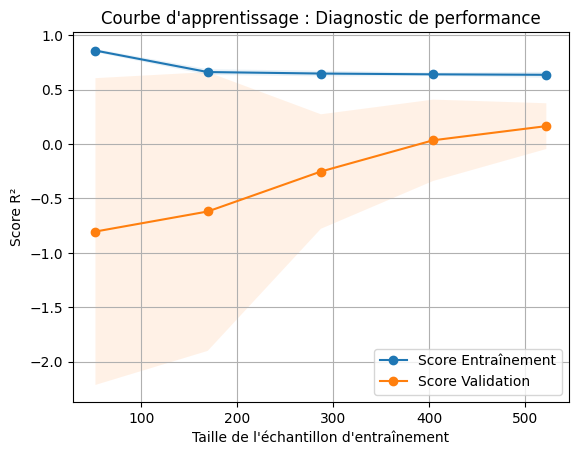

In [77]:
# COMPARAISON DES PERFORMANCES

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeRegressor(max_depth=5), X, y, cv=5, scoring='r2', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Score Entraînement', marker='o')
plt.plot(train_sizes, test_mean, label='Score Validation', marker='o')
plt.fill_between(train_sizes, train_mean - np.std(train_scores, axis=1), train_mean + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes, test_mean - np.std(test_scores, axis=1), test_mean + np.std(test_scores, axis=1), alpha=0.1)

plt.title("Courbe d'apprentissage : Diagnostic de performance")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
# Frontières de décision (k-NN)
# Pour visualiser en 2D, on prend 2 variables
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train[['Hour', 'DayOfWeek']], y_train)
# (Visualisation complexe pour une régression, on se focalise sur le score)
print(f"Score k-NN: {knn.score(X_test[['Hour', 'DayOfWeek']], y_test)}")

Score k-NN: 0.3307253682871597


C:\Users\isddi\AppData\Local\Temp\ipykernel_52716\3850953301.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  futur_dates = pd.date_range(start='2018-01-01', end='2018-12-31', freq='H')
C:\Users\isddi\AppData\Local\Temp\ipykernel_52716\3850953301.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_forecast, x='Month', y='Predicted_Sales', palette='viridis', edgecolor='black')


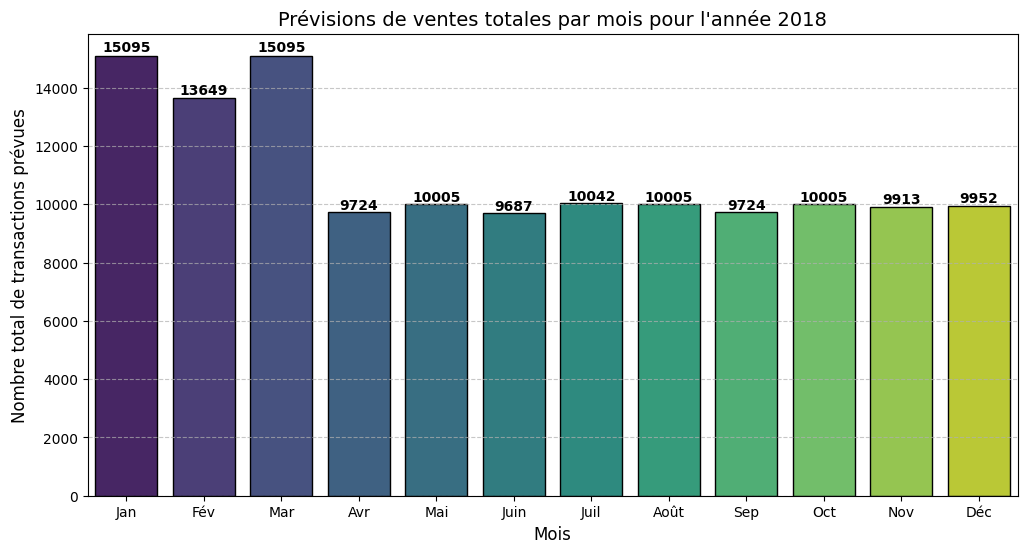

In [79]:
# 1. Créer un calendrier pour l'année complète (2018)
futur_dates = pd.date_range(start='2018-01-01', end='2018-12-31', freq='H')
df_futur = pd.DataFrame({'DateTime': futur_dates})

# 2. Extraire les caractéristiques temporelles
df_futur['Month'] = df_futur['DateTime'].dt.month
df_futur['DayOfWeek'] = df_futur['DateTime'].dt.dayofweek
df_futur['Hour'] = df_futur['DateTime'].dt.hour

# 3. Prédire le volume de ventes (basé sur ton model_tree)
X_futur = df_futur[['Month', 'DayOfWeek', 'Hour']]
df_futur['Predicted_Sales'] = model_tree.predict(X_futur)

# 4. AGRÉGATION : Sommer les prédictions par mois
# On transforme les prédictions horaires en volume total mensuel
monthly_forecast = df_futur.groupby('Month')['Predicted_Sales'].sum().reset_index()

# 5. Visualisation par mois
plt.figure(figsize=(12,6))
sns.barplot(data=monthly_forecast, x='Month', y='Predicted_Sales', palette='viridis', edgecolor='black')

# Personnalisation pour un rendu professionnel
plt.title("Prévisions de ventes totales par mois pour l'année 2018", fontsize=14)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Nombre total de transactions prévues", fontsize=12)
plt.xticks(ticks=range(12), labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajouter les valeurs au-dessus des barres
for i, val in enumerate(monthly_forecast['Predicted_Sales']):
    plt.text(i, val + (val*0.01), f'{int(val)}', ha='center', fontsize=10, fontweight='bold')

plt.show()